# 33 - Largest numerically stable kappa_acc (a_t = 0.09, strategy 5)

Sweeps kappa_acc from 2 to 600 at a_t_acc = 0.09 and checks, for several strategy-5 precision settings, whether
CLASS runs, returns finite spectra and agrees with a high-resolution reference.

Two effects limit kappa:

- **Resolution.** 98% of the daughters are born within Δln a ≈ 9.2/κ around a_t, while strategy 5 spreads its
  nodes evenly in ln a_q over [a_min, 1]. With N nodes, about (N−1)·(9.2/κ)/ln(1/a_min) of them fall inside the
  birth epoch: 51 bins give about one node at κ ≈ 190.
- **Overflow.** CLASS evaluates y = (a/a_t)^κ directly. At a_q = 1, y is inf in double precision for
  κ > ln(DBL_MAX)/ln(1/a_t) ≈ 294.8, and the birth rate κ(x+y)/(1+y)² becomes inf/inf = NaN
  (`background_acc_birth_rate`; Γ_acc and dln f0/dln q have the same form). No precision setting avoids this.

Section 1 predicts both from the grid alone; sections 2–4 run CLASS.

- **Settings:** ΛCDM best fit and chain settings of `connect/Lite_lin/11` (as in nb32), m = 10¹¹ GeV,
  f_acc = 0.01, no DE sink. Only kappa and the daughter precision change.
- **Reference:** strategy 5 with 801 bins; 401 vs 801 estimates its own error.
- **Stable** at kappa: CLASS runs, all outputs are finite, Δχ² vs the reference < 0.1 and max |ΔP_cb/P_cb| < 1e-3.

Runtime about 1.5 h, mostly the 401/801-bin runs. Each run is a forked process with a timeout, so a crash or hang
at large kappa is recorded instead of stopping the notebook. Results are cached in `33_cache.pkl`; delete it after
rebuilding CLASS.

In [ ]:
import json
import multiprocessing as mp
import pickle
import queue
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


BF = read_bestfit(find_root()/'chains'/'fixed_masses'/'connect'/'Lite_lin'/'11'/'11_lin.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'omega_cdm', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}

A_T = 0.09
F_ACC = 1e-2
F_NULL = 1e-6                     # signal reference; accDM needs f_acc > 0
KAPPAS = [2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 250, 290
          #, 294, 295, 300, 350, 400, 500, 600
          ]
K_OVERFLOW = np.log(np.finfo(float).max)/np.log(1/A_T)    # (1/a_t)^kappa is inf above this

# connect/Lite_lin/11 settings with a_t = 0.09, strategy 5 and no DE sink; kappa and precision are set per run
SETTINGS = {'N_ncdm': 2, 'N_ur': 2.0308,
            'm_ncdm': '0.06, 0.1', 'deg_ncdm': '1, 1', 'T_ncdm': '0.71611, 1.0',
            'm_acc_in_GeV': 1e11, 'a_t_acc': A_T, 'vary_Gamma_acc': 'yes', 'acc_de_sink': 'no',
            'ncdm_quadrature_strategy': '0, 5', 'ncdm_fluid_approximation': 3,
            'gauge': 'synchronous', 'reionization_z_start_max': 80, 'evolver': 0,
            'output': 'mPk, lCl, tCl, pCl', 'P_k_max_1/Mpc': 1.0, 'lensing': 'yes', 'l_max_scalars': 2508}


def bins(n):
    return {'ncdm_N_momentum_bins': '15, {:d}'.format(n)}


# label: daughter precision parameters on top of SETTINGS
SETUPS = {'s5 51': bins(51),                     # production (params/1e11GeV.param)
          's5 101': bins(101),
          's5 201': bins(201),
          's5 401': bins(401),
          's5 801': bins(801),
          's5 50/dec': {},                       # default accdm_q_bins_per_decade
          's5 200/dec': {'accdm_q_bins_per_decade': 200},
          's5 51, q_tol 1e-9': {**bins(51), 'accdm_q_number_tol': 1e-9},
          's5 51, tol_pert 1e-6': {**bins(51), 'tol_perturbations_integration': 1e-6},
          's5 51, smooth births': {**bins(51), 'accdm_smooth_births': 1}
          }
PROD = 's5 51'
REF = 's5 801'
REF_CHECK = 's5 401'              # REF_CHECK vs REF estimates the reference error

print('LCDM best fit:', LCDM)
print('y = (a_q/a_t)^kappa overflows at a_q = 1 for kappa > {:.2f}'.format(K_OVERFLOW))

LCDM best fit: {'omega_b': 0.02256944, 'omega_cdm': 0.1175042, 'H0': 68.47743, 'ln10^{10}A_s': 3.056426, 'n_s': 0.972248, 'tau_reio': 0.06151263}
y = (a_q/a_t)^kappa overflows at a_q = 1 for kappa > 294.77


## 1. Grid diagnostics without CLASS

Rebuilds the strategy-5 grid as CLASS does (a_min by bisection on F(a_min) = accdm_q_number_tol, an odd number of
nodes uniform in ln a_q on [a_min, 1], Simpson weights) and integrates the birth rate dF/dln a over it.

- **nodes in birth:** nodes with 0.01 < F < 0.99.
- **Simpson error:** ∫ dF against the exact 1 − F(a_min), and the momentum-weighted ∫ a_q dF against a
  400001-node integral. Both use an overflow-safe rate, so they measure resolution only.
- **NaN:** nodes where the rate as CLASS writes it is NaN in double precision.

q_size / nodes in birth per grid; NaN = nodes where the CLASS birth rate is NaN (s5 51 grid)
 kappa     a_min  NaN          51         101         201         401         801      50/dec     200/dec   51, q_tol
     2  8.96e-05    0       51/23      101/46      201/93     401/185     801/370      205/95     811/374       51/17
     3  9.00e-04    0       51/22      101/44      201/87     401/173     801/347      155/67     611/264       51/17
     5  5.68e-03    0       51/18      101/36      201/71     401/142     801/284      115/41     451/160       51/14
     8  1.60e-02    0       51/14      101/28      201/56     401/111     801/223       91/25     361/100       51/11
    12  2.85e-02    0       51/11      101/22      201/43      401/86     801/172       79/17      311/67        51/9
    20  4.51e-02    0        51/7      101/15      201/30      401/59     801/118       69/10      271/40        51/7
    30  5.68e-02    0        51/5      101/11      201/21      401/43      801/86

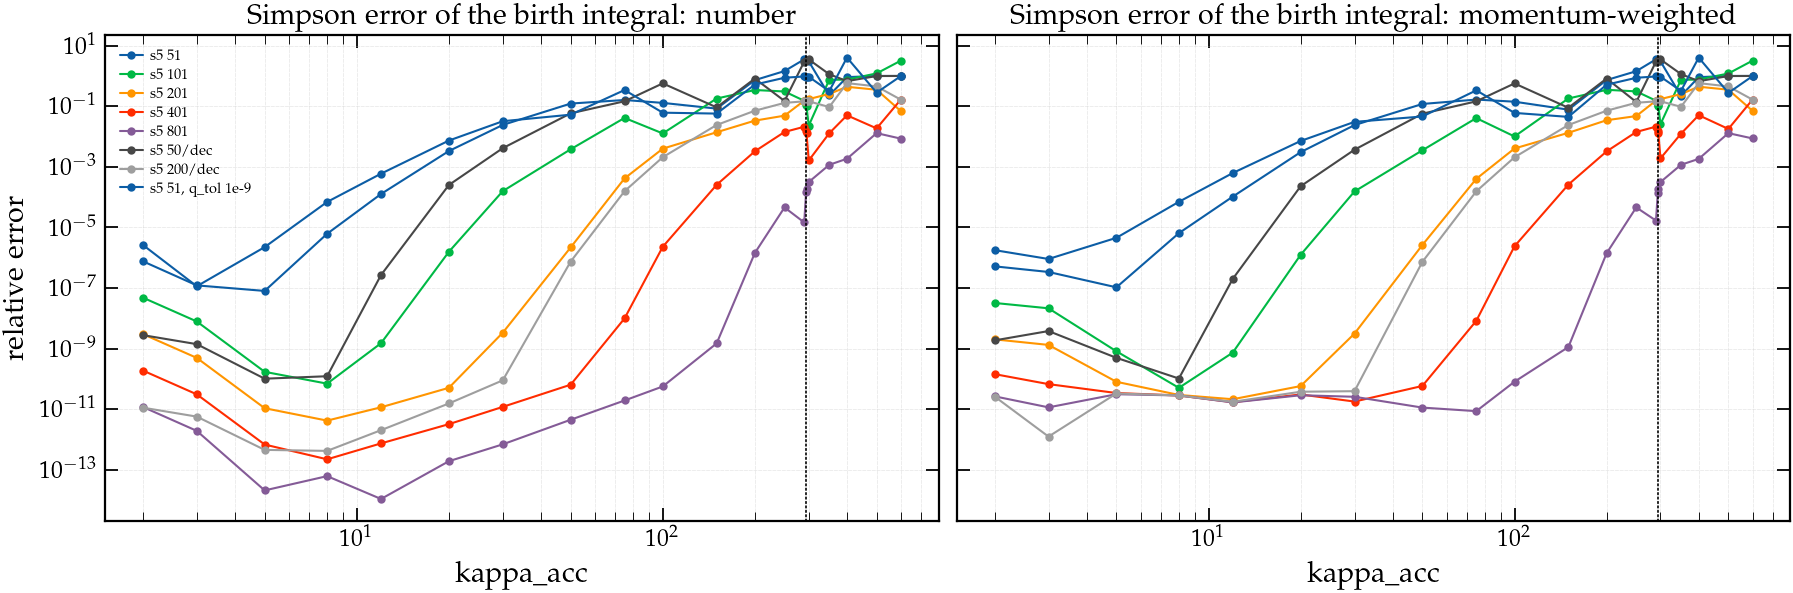

In [2]:
def born_fraction(a, kappa):
    """F(a) as in background_acc_born_fraction; an overflowing y correctly gives F = 1."""
    with np.errstate(over='ignore'):
        return 1 - (1 - a**kappa)/(1 + (a/A_T)**kappa)


def rate_class(lna, kappa):
    """dF/dln a written as in background_acc_birth_rate (NaN once y overflows)."""
    a = np.exp(lna)
    with np.errstate(over='ignore', invalid='ignore'):
        x, y = a**kappa, (a/A_T)**kappa
        return kappa*(x + y)/(1 + y)**2


def rate_safe(lna, kappa):
    """dF/dln a written in 1/y where y > 1."""
    lny = kappa*(lna - np.log(A_T))
    x = np.exp(kappa*lna)
    u = np.exp(-np.abs(lny))                     # min(y, 1/y)
    return np.where(lny > 0, kappa*(x*u + 1)*u/(1 + u)**2, kappa*(x + u)/(1 + u)**2)


def a_min_class(kappa, eps):
    """background_acc_a_min: bisection in ln a on [1e-14, 1]."""
    lo, hi = np.log(1e-14), 0.0
    if born_fraction(np.exp(lo), kappa) >= eps:
        return np.exp(lo)
    for _ in range(100):
        mid = 0.5*(lo + hi)
        if born_fraction(np.exp(mid), kappa) < eps:
            lo = mid
        else:
            hi = mid
        if hi - lo < 1e-10:
            break
    return np.exp(lo)


def grid_size(kappa, extra):
    """a_min and daughter q_size as input.c sets them."""
    a_min = a_min_class(kappa, extra.get('accdm_q_number_tol', 1e-6))
    if 'ncdm_N_momentum_bins' in extra:
        n = int(extra['ncdm_N_momentum_bins'].split(',')[1])
    else:
        n = max(3, int(np.ceil(extra.get('accdm_q_bins_per_decade', 50.0)*np.log10(1/a_min))) + 1)
    return a_min, n + (n % 2 == 0)


def simpson(lna, f):
    w = np.ones(len(lna))
    w[1:-1:2], w[2:-1:2] = 4, 2
    return (lna[1] - lna[0])/3*np.sum(w*f)


def grid_diagnostics(kappa, extra):
    a_min, n = grid_size(kappa, extra)
    lna = np.linspace(np.log(a_min), 0.0, n)
    fine = np.linspace(np.log(a_min), 0.0, 400001)
    r = rate_safe(lna, kappa)
    exact_n = 1 - born_fraction(a_min, kappa)
    exact_p = simpson(fine, rate_safe(fine, kappa)*np.exp(fine))
    F = born_fraction(np.exp(lna), kappa)
    return {'a_min': a_min, 'n': n,
            'in_birth': int(np.sum((F > 0.01) & (F < 0.99))),
            'err_n': abs(simpson(lna, r)/exact_n - 1),
            'err_p': abs(simpson(lna, r*np.exp(lna))/exact_p - 1),
            'nan_nodes': int(np.sum(~np.isfinite(rate_class(lna, kappa))))}


# settings that change the grid
GRID_SETUPS = [lab for lab in SETUPS if 'tol_pert' not in lab and 'smooth' not in lab]
diag = {(lab, k): grid_diagnostics(k, SETUPS[lab]) for lab in GRID_SETUPS for k in KAPPAS}

print('q_size / nodes in birth per grid; NaN = nodes where the CLASS birth rate is NaN ({} grid)'.format(PROD))
print('{:>6} {:>9} {:>4}'.format('kappa', 'a_min', 'NaN') + ''.join('{:>12}'.format(lab[3:12]) for lab in GRID_SETUPS))
for k in KAPPAS:
    d0 = diag[(PROD, k)]
    print('{:>6g} {:>9.2e} {:>4d}'.format(k, d0['a_min'], d0['nan_nodes'])
          + ''.join('{:>12s}'.format('{}/{}'.format(diag[(lab, k)]['n'], diag[(lab, k)]['in_birth']))
                    for lab in GRID_SETUPS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)
for ax, key, name in zip(axes, ('err_n', 'err_p'), ('number', 'momentum-weighted')):
    for lab in GRID_SETUPS:
        ax.loglog(KAPPAS, [max(diag[(lab, k)][key], 1e-16) for k in KAPPAS], 'o-', ms=3, lw=1, label=lab)
    ax.axvline(K_OVERFLOW, color='k', ls=':', lw=0.8)
    ax.set_title('Simpson error of the birth integral: ' + name)
    ax.set_xlabel('kappa_acc')
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('relative error')
axes[0].legend(fontsize=7)
plt.show()

## 2. CLASS runs

Kappa is the outer loop, so every setting finishes at small kappa before the overflow region. The null run
(f_acc = 1e-6) sets the signal scale.

In [3]:
LMAX = 2500
ELL = np.arange(2, LMAX + 1)
KK = np.logspace(-4, np.log10(0.9), 300)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
TIMEOUT = 900.0                                                      # s per run
CACHE = Path('33_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def params(kappa, lab, f_acc=F_ACC):
    return {**LCDM, **SETTINGS, **SETUPS[lab], 'kappa_acc': float(kappa), 'f_acc': f_acc}


def run(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        out['pk_m'] = np.array([cosmo.pk(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out.update(cosmo.get_current_derived_parameters(['100*theta_s', 'Omega_Lambda', 'sigma8']))
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
        bg = cosmo.get_background()
        out['Omega_acc'] = bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    out['finite'] = bool(all(np.all(np.isfinite(v)) for v in out.values()))
    return out


def _child(p, q):
    try:
        q.put(run(p))
    except Exception as err:
        q.put({'error': '{}: {}'.format(type(err).__name__, err)})


def run_isolated(p):
    """run(p) in a forked child, so a crash or hang becomes an error entry."""
    ctx = mp.get_context('fork')
    q = ctx.Queue()
    proc = ctx.Process(target=_child, args=(p, q))
    t0 = time.time()
    proc.start()
    out = None
    while out is None:
        try:
            out = q.get(timeout=1.0)
        except queue.Empty:
            if not proc.is_alive():
                try:
                    out = q.get(timeout=2.0)
                except queue.Empty:
                    out = {'error': 'CLASS process died, exit code {}'.format(proc.exitcode)}
            elif time.time() - t0 > TIMEOUT:
                proc.kill()
                out = {'error': 'timeout after {:.0f} s'.format(TIMEOUT)}
    proc.join()
    out['sec'] = time.time() - t0
    return out


def cached_run(p):
    key = json.dumps(p, sort_keys=True)
    if key not in cache:
        cache[key] = run_isolated(p)
        CACHE.write_bytes(pickle.dumps(cache))
    return cache[key]


def ok(out):
    return 'error' not in out and out['finite']


def status(out, n=90):
    if 'error' in out:
        lines = [s.strip() for s in out['error'].splitlines() if s.strip()]
        return 'ERROR ' + (lines[-1] if lines else out['error'])[:n]
    return 'ok' if out['finite'] else 'NON-FINITE'

In [4]:
null = cached_run(params(5, PROD, F_NULL))
print('null run (kappa = 5, f_acc = {:g}): {}'.format(F_NULL, status(null)))
assert ok(null)

res = {}
for kappa in KAPPAS:
    for lab in SETUPS:
        res[(lab, kappa)] = out = cached_run(params(kappa, lab))
        print('kappa {:>4g}  {:<22s} {:5.0f} s  {}'.format(kappa, lab, out['sec'], status(out)))

null run (kappa = 5, f_acc = 1e-06): ok
kappa    2  s5 51                      9 s  ok
kappa    2  s5 101                    10 s  ok
kappa    2  s5 201                    20 s  ok
kappa    2  s5 401                    49 s  ok
kappa    2  s5 801                   120 s  ok
kappa    2  s5 50/dec                 24 s  ok
kappa    2  s5 200/dec               142 s  ok
kappa    2  s5 51, q_tol 1e-9          8 s  ok
kappa    2  s5 51, tol_pert 1e-6      12 s  ok
kappa    2  s5 51, smooth births       7 s  ok
kappa    3  s5 51                      7 s  ok
kappa    3  s5 101                    13 s  ok
kappa    3  s5 201                    27 s  ok
kappa    3  s5 401                    54 s  ok
kappa    3  s5 801                   123 s  ok
kappa    3  s5 50/dec                 20 s  ok
kappa    3  s5 200/dec                82 s  ok
kappa    3  s5 51, q_tol 1e-9          6 s  ok
kappa    3  s5 51, tol_pert 1e-6       8 s  ok
kappa    3  s5 51, smooth births      10 s  ok
kappa    5  s5 51   

## 3. Stability verdict

Δχ² is the nb32 approximation (Planck-like CMB, 2.5% lensing amplitude, 1% DESI-like BAO); ΛCDM parameters are
fixed, so it is a conservative sensitivity scale rather than a likelihood. Each setting is compared with the
801-bin reference at the same kappa. The reference itself counts as stable where 401 vs 801 is below a tenth of
both tolerances.

kappa_max is the largest grid kappa up to which every kappa passes.

In [5]:
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)
DCHI2_TOL = 0.1
PK_TOL = 1e-3


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def compare(lab, kappa, base=REF):
    a, b = res[(lab, kappa)], res[(base, kappa)]
    if not (ok(a) and ok(b)):
        return None
    return {'dchi2': chi2_parts(a, b)['total'],
            'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1))),
            'domega': a['Omega_acc']/b['Omega_acc'] - 1,
            'dsigma8': a['sigma8_cb']/b['sigma8_cb'] - 1}


def ref_converged(kappa):
    c = compare(REF_CHECK, kappa)
    return c is not None and c['dchi2'] < DCHI2_TOL/10 and c['dpk'] < PK_TOL/10


def verdict(lab, kappa):
    out = res[(lab, kappa)]
    if 'error' in out:
        return 'E'
    if not out['finite']:
        return 'N'
    if lab == REF:
        return '.' if ref_converged(kappa) else 'u'
    c = compare(lab, kappa)
    if c is None:
        return '?'
    if c['dchi2'] > DCHI2_TOL:
        return 'X'
    if c['dpk'] > PK_TOL:
        return 'P'
    return '.'


def kappa_max(lab):
    """Largest grid kappa up to which every kappa passes, and the first failure."""
    last = None
    for k in KAPPAS:
        v = verdict(lab, k)
        if v != '.':
            return last, (k, v)
        last = k
    return last, None


print('.  stable      X  dchi2 > {:g}      P  max|dP_cb/P_cb| > {:g}'.format(DCHI2_TOL, PK_TOL))
print('N  non-finite  E  CLASS error or timeout   ?  reference failed   u  reference: 401 vs 801 above tol/10')
cols = list(SETUPS)
for i, lab in enumerate(cols):
    print('  [{}] {}'.format(i, lab))
print('{:>6}'.format('kappa') + ''.join('{:>5}'.format('[{}]'.format(i)) for i in range(len(cols))))
for k in KAPPAS:
    print('{:>6g}'.format(k) + ''.join('{:>5}'.format(verdict(lab, k)) for lab in cols))

print()
print('largest stable kappa')
for lab in cols:
    km, fail = kappa_max(lab)
    first = 'first failure at kappa = {:g} ({})'.format(*fail) if fail else 'no failure up to {:g}'.format(KAPPAS[-1])
    print('  {:<22s} kappa_max = {:>5}   {}'.format(lab, 'none' if km is None else '{:g}'.format(km), first))

print()
print('{} vs {}; signal = {} vs null run; ref err = {} vs {}'.format(PROD, REF, REF, REF_CHECK, REF))
print('{:>6} {:>9} {:>10} {:>11} {:>11} {:>9} {:>9}'.format(
    'kappa', 'dchi2', 'max dPcb', 'dOmega_acc', 'dsigma8_cb', 'signal', 'ref err'))
for k in KAPPAS:
    c, r = compare(PROD, k), compare(REF_CHECK, k)
    if c is None:
        bad = [lab for lab in (PROD, REF) if not ok(res[(lab, k)])]
        print('{:>6g}  {}: {}'.format(k, bad[0], status(res[(bad[0], k)])))
        continue
    sig = chi2_parts(res[(REF, k)], null)['total']
    print('{:>6g} {:>9.2e} {:>10.2e} {:>+11.2e} {:>+11.2e} {:>9.3g} {:>9.2e}'.format(
        k, c['dchi2'], c['dpk'], c['domega'], c['dsigma8'], sig, r['dchi2'] if r else np.nan))

.  stable      X  dchi2 > 0.1      P  max|dP_cb/P_cb| > 0.001
N  non-finite  E  CLASS error or timeout   ?  reference failed   u  reference: 401 vs 801 above tol/10
  [0] s5 51
  [1] s5 101
  [2] s5 201
  [3] s5 401
  [4] s5 801
  [5] s5 50/dec
  [6] s5 200/dec
  [7] s5 51, q_tol 1e-9
  [8] s5 51, tol_pert 1e-6
  [9] s5 51, smooth births
 kappa  [0]  [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]  [9]
     2    .    .    .    .    .    .    .    .    .    P
     3    .    .    .    .    u    .    .    .    .    P
     5    .    .    .    .    u    .    .    .    .    P
     8    .    .    .    .    u    .    .    .    .    P
    12    .    .    .    .    .    .    .    .    .    P
    20    .    .    .    .    .    .    .    .    .    P
    30    .    .    .    .    .    P    .    X    .    P
    50    X    P    .    .    .    X    .    X    X    X
    75    X    X    .    .    .    X    .    X    X    X
   100    X    X    P    .    .    X    .    X    X    X
   150    X    X    X    P    u  

## 4. Plots

Top: errors against the reference, with the tolerances (dashed) and the overflow kappa (dotted). The last panel
shows the signal and the reference error on the same Δχ² scale. Middle: observables vs kappa, where jumps or
zig-zags between neighbouring kappa mark instability; at large kappa the curves should flatten as birth
approaches a step at a_t. Bottom: P_cb against the reference at a few kappa.

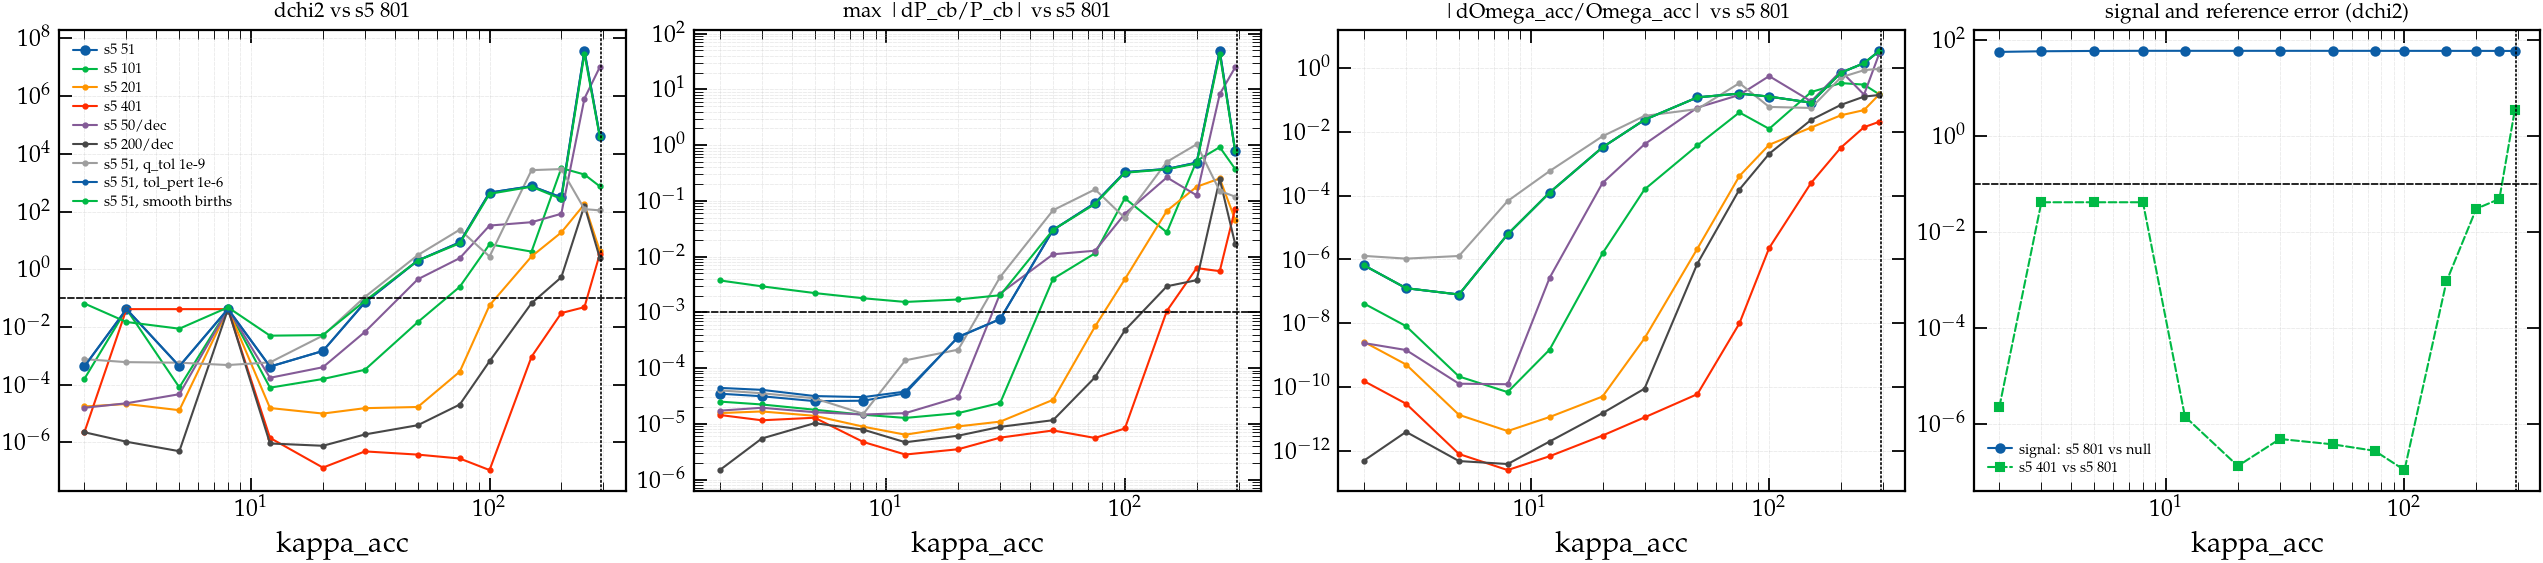

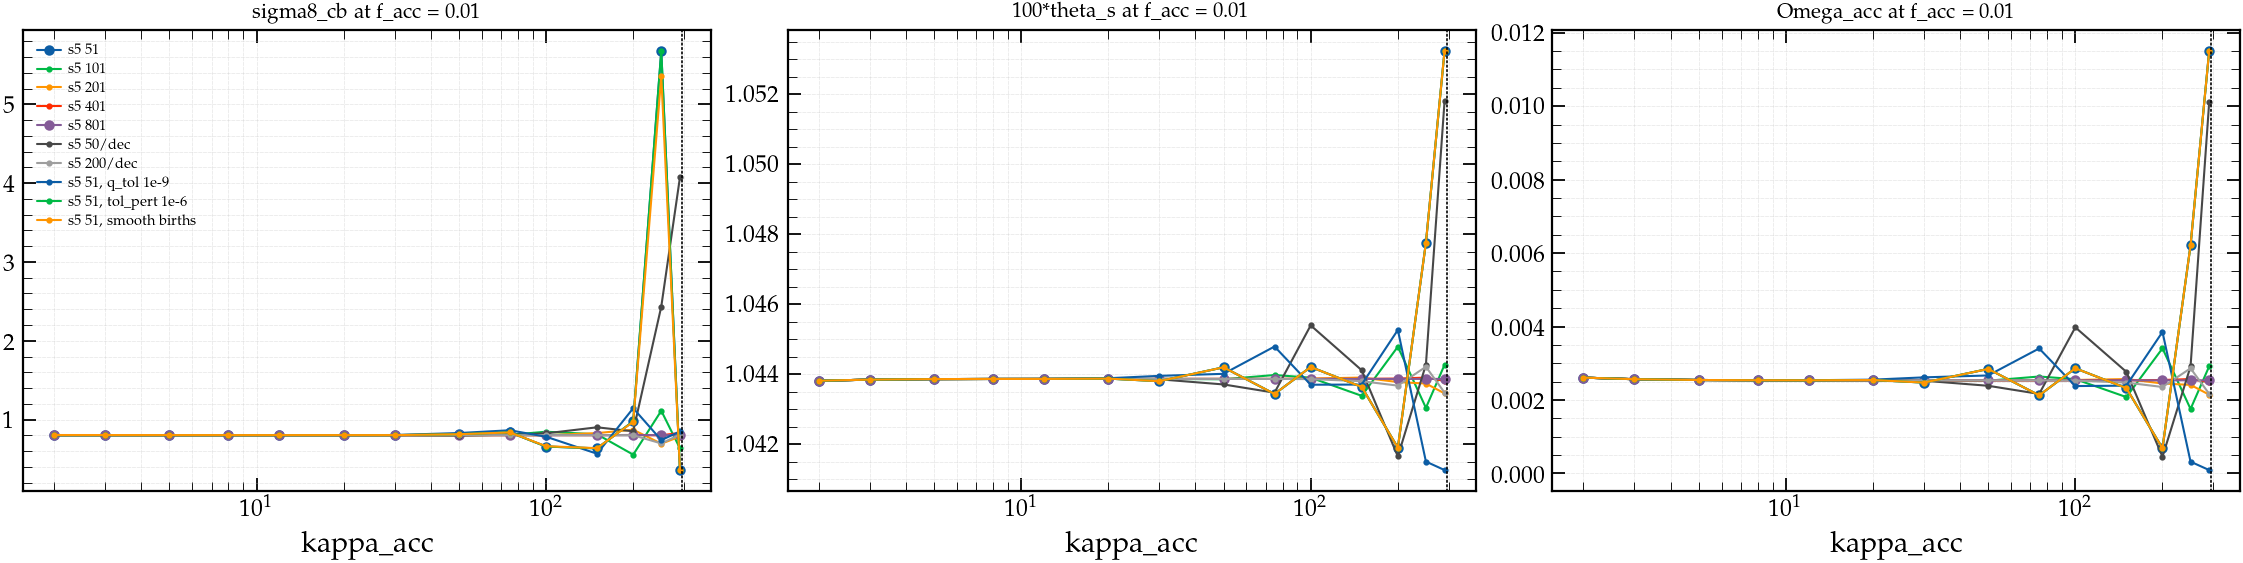

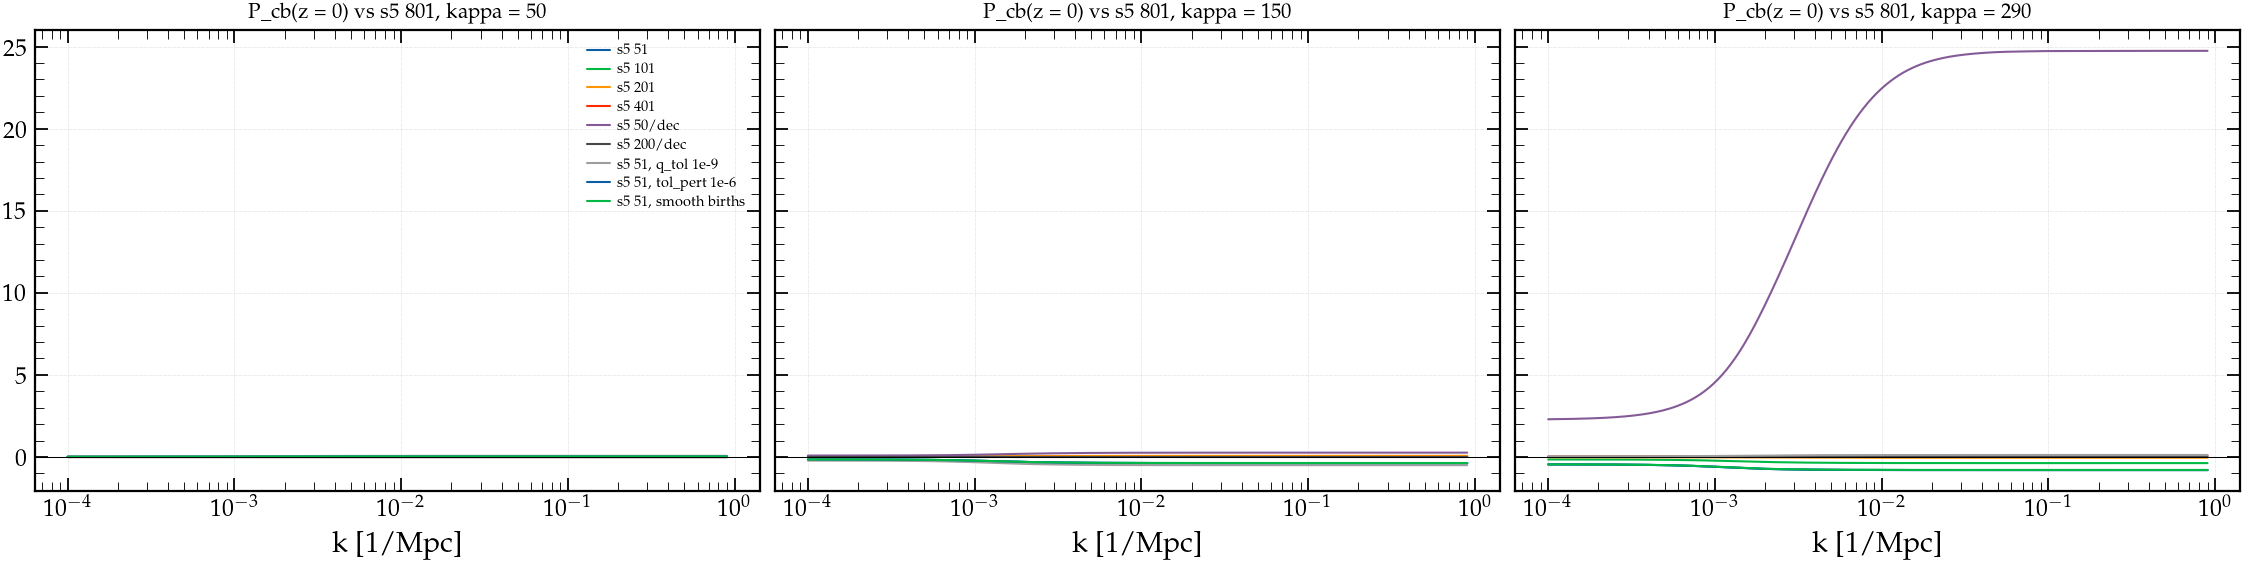

In [6]:
LABS = [lab for lab in SETUPS if lab != REF]


def style(lab):
    return 'o-' if lab in (PROD, REF) else '.-'


fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), constrained_layout=True)
for ax, (key, name, tol) in zip(axes, [('dchi2', 'dchi2 vs ' + REF, DCHI2_TOL),
                                       ('dpk', 'max |dP_cb/P_cb| vs ' + REF, PK_TOL),
                                       ('domega', '|dOmega_acc/Omega_acc| vs ' + REF, None)]):
    for lab in LABS:
        pts = [(k, compare(lab, k)) for k in KAPPAS]
        pts = [(k, max(abs(c[key]), 1e-16)) for k, c in pts if c is not None]
        if pts:
            ax.loglog(*zip(*pts), style(lab), ms=4, lw=1, label=lab)
    if tol:
        ax.axhline(tol, color='k', ls='--', lw=0.8)
    ax.set_title(name, fontsize=10)
sig = [(k, chi2_parts(res[(REF, k)], null)['total']) for k in KAPPAS if ok(res[(REF, k)])]
err = [(k, max(compare(REF_CHECK, k)['dchi2'], 1e-16)) for k in KAPPAS if compare(REF_CHECK, k)]
if sig:
    axes[3].loglog(*zip(*sig), 'o-', ms=4, lw=1, label='signal: {} vs null'.format(REF))
if err:
    axes[3].loglog(*zip(*err), 's--', ms=4, lw=1, label='{} vs {}'.format(REF_CHECK, REF))
axes[3].axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
axes[3].set_title('signal and reference error (dchi2)', fontsize=10)
axes[3].legend(fontsize=7)
for ax in axes:
    ax.axvline(K_OVERFLOW, color='k', ls=':', lw=0.8)
    ax.set_xlabel('kappa_acc')
    ax.grid(alpha=0.3, which='both')
axes[0].legend(fontsize=7)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)
for ax, key in zip(axes, ('sigma8_cb', '100*theta_s', 'Omega_acc')):
    for lab in SETUPS:
        pts = [(k, res[(lab, k)][key]) for k in KAPPAS if ok(res[(lab, k)])]
        if pts:
            ax.semilogx(*zip(*pts), style(lab), ms=4, lw=1, label=lab)
    ax.axvline(K_OVERFLOW, color='k', ls=':', lw=0.8)
    ax.set_title('{} at f_acc = {:g}'.format(key, F_ACC), fontsize=10)
    ax.set_xlabel('kappa_acc')
    ax.grid(alpha=0.3, which='both')
axes[0].legend(fontsize=7)
plt.show()

KAPPA_SHOW = [k for k in (50, 150, 290) if k in KAPPAS]
fig, axes = plt.subplots(1, len(KAPPA_SHOW), figsize=(5*len(KAPPA_SHOW), 3.8), sharey=True,
                         constrained_layout=True, squeeze=False)
for ax, k in zip(axes[0], KAPPA_SHOW):
    for lab in LABS:
        if compare(lab, k) is not None:
            ax.semilogx(KK, res[(lab, k)]['pk_cb']/res[(REF, k)]['pk_cb'] - 1, lw=1, label=lab)
    ax.axhspan(-PK_TOL, PK_TOL, color='0.9', lw=0)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title('P_cb(z = 0) vs {}, kappa = {:g}'.format(REF, k), fontsize=10)
    ax.set_xlabel('k [1/Mpc]')
    ax.grid(alpha=0.3)
axes[0][0].legend(fontsize=7)
plt.show()

## 5. Is large κ distinguishable from κ = 30?

Compares the 801-bin run at each κ with the 801-bin run at κ = 30, where every setting from 51 bins up agrees.
If Δχ² stays well below 0.1 above κ = 30, κ = 30 can stand in for any larger κ at this f_acc. A row means
something only where the κ difference exceeds the reference error (401 vs 801 at that κ); other rows are
flagged. A ~0.04 Δχ² jump that does not depend on bin count (κ = 3–8 above, and nb32) sets a floor.
Δχ² scales roughly as f_acc², so at the ~5e-3 limits it is about 4× smaller than shown.

s5 801 at each kappa vs s5 801 at kappa = 30; ref err = s5 401 vs s5 801 at that kappa
 kappa     dchi2       CMB      lens       BAO   max dPcb  dsigma8_cb  dOmega_acc   ref err
     2  7.25e-02  6.61e-02  4.24e-03  2.19e-03   2.09e-03   +2.46e-04   +2.91e-02  2.28e-06
     3  2.70e-02  2.41e-02  1.73e-03  1.12e-03   1.01e-03   +1.55e-04   +1.23e-02  4.13e-02  numerics
     5  1.02e-02  9.73e-03  2.82e-04  2.27e-04   3.55e-04   +5.04e-05   +3.58e-03  4.14e-02  numerics
     8  4.54e-02  4.54e-02  3.17e-05  3.23e-05   1.29e-04   +1.68e-05   +1.20e-03  4.14e-02
    12  1.23e-03  1.22e-03  6.60e-06  5.02e-06   5.02e-05   +6.36e-06   +4.66e-04  1.43e-06
    20  1.27e-04  1.26e-04  5.23e-07  2.72e-07   1.20e-05   +1.61e-06   +1.09e-04  1.33e-07
    30  0.00e+00  0.00e+00  0.00e+00  0.00e+00   0.00e+00   +0.00e+00   +0.00e+00  4.86e-07
    50  1.11e-04  1.11e-04  1.50e-08  7.54e-08   7.77e-06   -1.23e-06   -5.52e-05  3.76e-07
    75  3.12e-04  3.12e-04  3.30e-08  1.27e-07   1.08e-05   -1.22

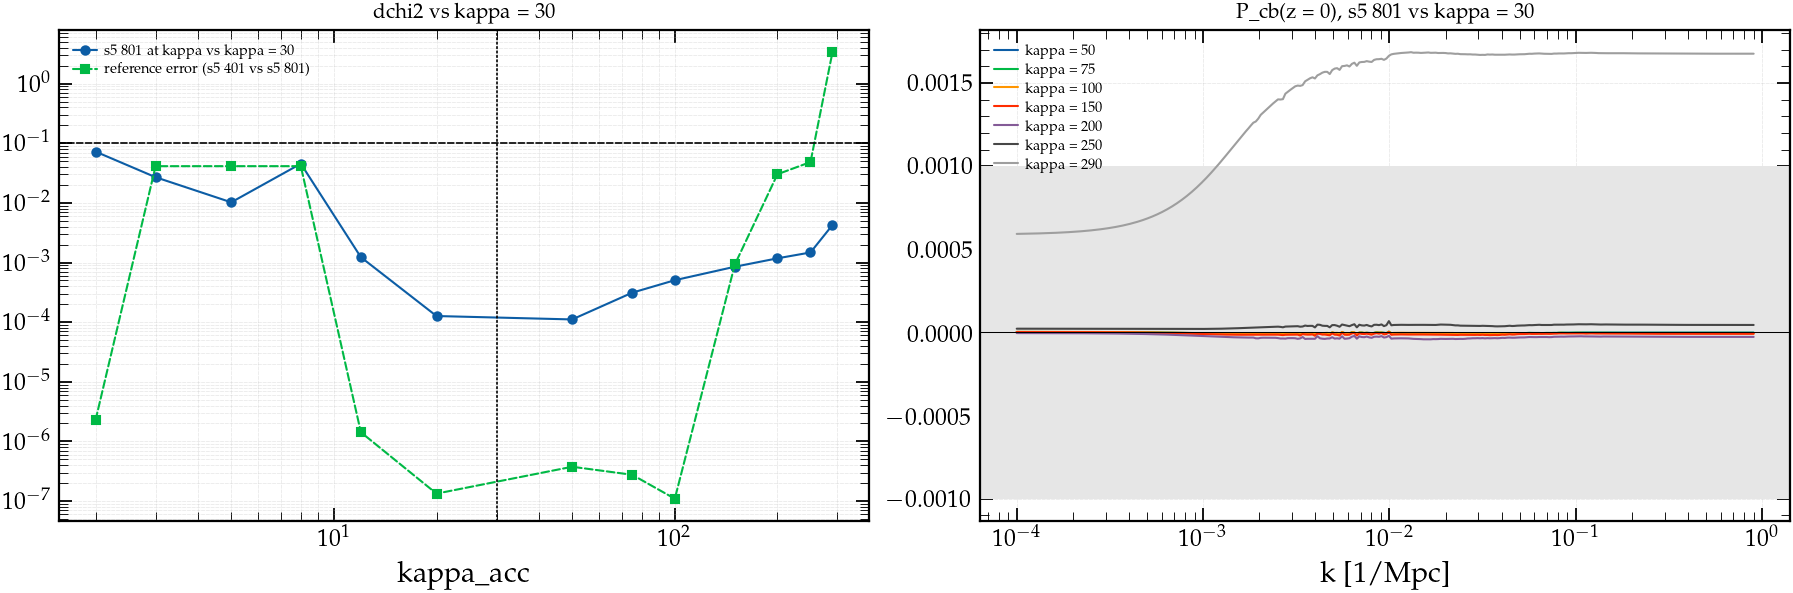

In [8]:
K_BASE = 30
base = res[(REF, K_BASE)]
assert ok(base)

print('{} at each kappa vs {} at kappa = {}; ref err = {} vs {} at that kappa'.format(
    REF, REF, K_BASE, REF_CHECK, REF))
print('{:>6} {:>9} {:>9} {:>9} {:>9} {:>10} {:>11} {:>11} {:>9}'.format(
    'kappa', 'dchi2', 'CMB', 'lens', 'BAO', 'max dPcb', 'dsigma8_cb', 'dOmega_acc', 'ref err'))
rows = []
for k in KAPPAS:
    a = res[(REF, k)]
    if not ok(a):
        print('{:>6g}  {}'.format(k, status(a)))
        continue
    c = chi2_parts(a, base)
    r = compare(REF_CHECK, k)
    rerr = r['dchi2'] if r else np.nan
    rows.append((k, c['total'], rerr))
    flag = '  numerics' if k != K_BASE and not rerr < c['total'] else ''
    print('{:>6g} {:>9.2e} {:>9.2e} {:>9.2e} {:>9.2e} {:>10.2e} {:>+11.2e} {:>+11.2e} {:>9.2e}{}'.format(
        k, c['total'], c['cmb'], c['lens'], c['bao'],
        float(np.max(np.abs(a['pk_cb']/base['pk_cb'] - 1))),
        a['sigma8_cb']/base['sigma8_cb'] - 1, a['Omega_acc']/base['Omega_acc'] - 1, rerr, flag))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
rest = [row for row in rows if row[0] != K_BASE]
axes[0].loglog([r[0] for r in rest], [max(r[1], 1e-16) for r in rest], 'o-', ms=4, lw=1,
               label='{} at kappa vs kappa = {}'.format(REF, K_BASE))
axes[0].loglog([r[0] for r in rest], [max(r[2], 1e-16) for r in rest], 's--', ms=4, lw=1,
               label='reference error ({} vs {})'.format(REF_CHECK, REF))
axes[0].axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
axes[0].axvline(K_BASE, color='k', ls=':', lw=0.8)
axes[0].set_title('dchi2 vs kappa = {}'.format(K_BASE), fontsize=10)
axes[0].set_xlabel('kappa_acc')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3, which='both')
for k in KAPPAS:
    if k > K_BASE and ok(res[(REF, k)]):
        axes[1].semilogx(KK, res[(REF, k)]['pk_cb']/base['pk_cb'] - 1, lw=1, label='kappa = {:g}'.format(k))
axes[1].axhspan(-PK_TOL, PK_TOL, color='0.9', lw=0)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('P_cb(z = 0), {} vs kappa = {}'.format(REF, K_BASE), fontsize=10)
axes[1].set_xlabel('k [1/Mpc]')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)
plt.show()

## Reading the result

- **kappa_max of `s5 51`** is the answer for the current scan settings; kappa_max of the 401/801-bin runs shows
  how far more bins can push it.
- **All settings fail at κ = 295 but pass at 294:** the ceiling is the double overflow of (a/a_t)^κ, independent
  of precision. Writing the rate, Γ_acc and dln f0/dln q in 1/y for y > 1 removes it (`background_acc_birth_rate`,
  `background_functions` for Γ_acc, and the daughter dln f0/dln q in `perturbations.c`); `rate_safe` above is
  that form.
- **Failures below 295 that improve with bins:** resolution. The CLASS Δχ² should rise where section 1 shows
  about one node or fewer in the birth epoch. Adding bins uniformly is inefficient there, since most nodes sit in
  [a_t, 1] where nothing is born; a grid concentrated around a_t would be the fix.
- **`u` at large κ:** the reference is not converged, so a `.` for another setting there is not conclusive.
- **`smooth births` vs `s5 51`:** smooth births spread each bin over its cell, so at large κ they replace the
  step by a ramp of one cell width; agreement with the reference there is not expected.